In [1]:
from model import *
from data import *

## Trajno Unet me të dhënat e membranës  

Të dhënat e membranës ndodhen në dosjen membrane/, dhe është një detyrë klasifikimi binar.

Forma e hyrjes për imazhin dhe maskën është e njëjtë: (batch_size, rreshta, kolona, kanali = 1)

### Trajno me gjenerator të të dhënave



Therrasim modelin e krijuar edhe e trainojme ate.
Struktura është krijuar si Unet (2015), por tani kemi përdorur funksione që janë zhvilluar gjatë këtyre viteve (mund të kontrolloni gjërat e reja dhe t’i tregoni profesorit për ndryshimet).

Shihni që forma e të dhënave (dimensionet) është (256, 256, 1) për hyrjen. Nëse është e nevojshme, mund ta ndryshoni këtë, përdorni ChatGPT ose rregulloni të dhënat tuaja duke i riformatuar ato.

In [2]:
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from model import unet  # Kjo është nëse ke ruajtur modelin në 'model.py'

# Parametrat për augmentimin e të dhënave
data_gen_args = dict(rotation_range=0.2,
                     width_shift_range=0.05,
                     height_shift_range=0.05,
                     shear_range=0.05,
                     zoom_range=0.05,
                     horizontal_flip=True,
                     fill_mode='nearest')

# Përdorimi i gjeneratorit të trajnimit
myGene = trainGenerator(2, 'data/membrane/train', 'image', 'label', data_gen_args, save_to_dir=None)

# Krijimi i modelit U-Net nga skedari 'model.py'
model = unet(input_size=(256, 256, 1))

# Kompilimi i modelit
model.compile(optimizer=Adam(lr=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Ruaj modelin nëse gjejmë modelin më të mirë gjatë trajnimit
model_checkpoint = ModelCheckpoint('unet_membrana.hdf5', monitor='loss', verbose=1, save_best_only=True)

# Trajnimi i modelit
model.fit_generator(myGene, steps_per_epoch=1000, epochs=10, callbacks=[model_checkpoint])


Found 30 images belonging to 1 classes.
Found 30 images belonging to 1 classes.


C:\Users\Perdorues\.conda\envs\pytorchenv\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)
C:\Users\Perdorues\AppData\Local\Temp\ipykernel_6976\3892472412.py:28: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(myGene, steps_per_epoch=1000, epochs=10, callbacks=[model_checkpoint])


Epoch 1/10
1000/1000 [==============================] - ETA: 0s - loss: 0.2344 - accuracy: 0.8948
Epoch 1: loss improved from inf to 0.23439, saving model to unet_membrana.hdf5
1000/1000 [==============================] - 115s 110ms/step - loss: 0.2344 - accuracy: 0.8948
Epoch 2/10
1000/1000 [==============================] - ETA: 0s - loss: 0.1588 - accuracy: 0.9302
Epoch 2: loss improved from 0.23439 to 0.15881, saving model to unet_membrana.hdf5
1000/1000 [==============================] - 111s 111ms/step - loss: 0.1588 - accuracy: 0.9302
Epoch 3/10
1000/1000 [==============================] - ETA: 0s - loss: 0.1332 - accuracy: 0.9414
Epoch 3: loss improved from 0.15881 to 0.13324, saving model to unet_membrana.hdf5
1000/1000 [==============================] - 111s 111ms/step - loss: 0.1332 - accuracy: 0.9414
Epoch 4/10
1000/1000 [==============================] - ETA: 0s - loss: 0.1154 - accuracy: 0.9494
Epoch 4: loss improved from 0.13324 to 0.11536, saving model to unet_membrana.

### Testojm Modelin dhe afishojme rezultatet e maskave te parashikuara

C:\Users\Perdorues\AppData\Local\Temp\ipykernel_6976\3606143399.py:24: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  results = model.predict_generator(testGene, steps=30, verbose=1)


30/30 [==============================] - 2s 16ms/step


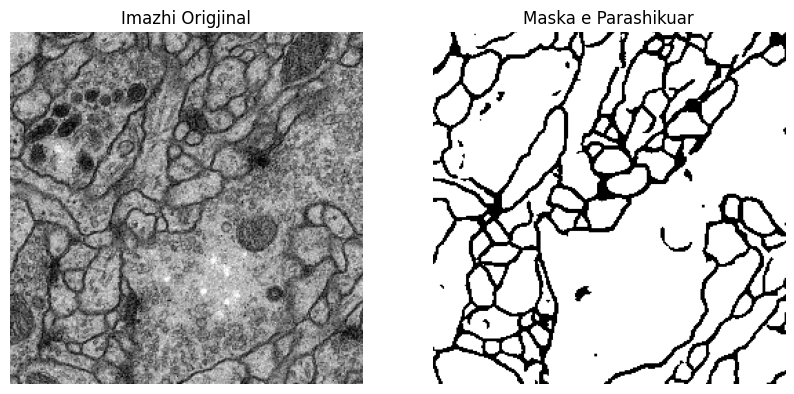

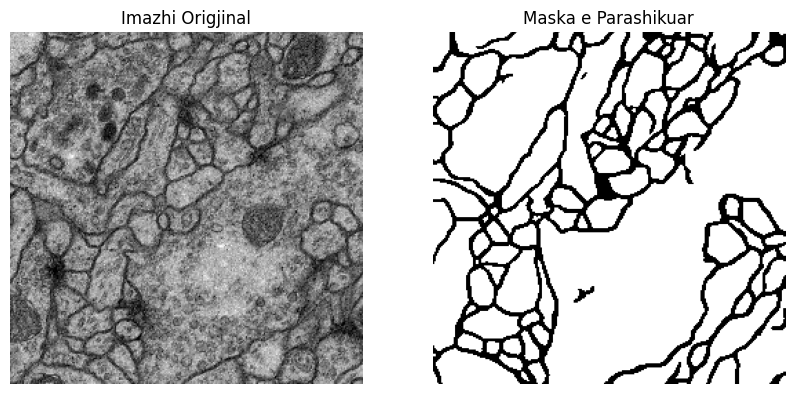

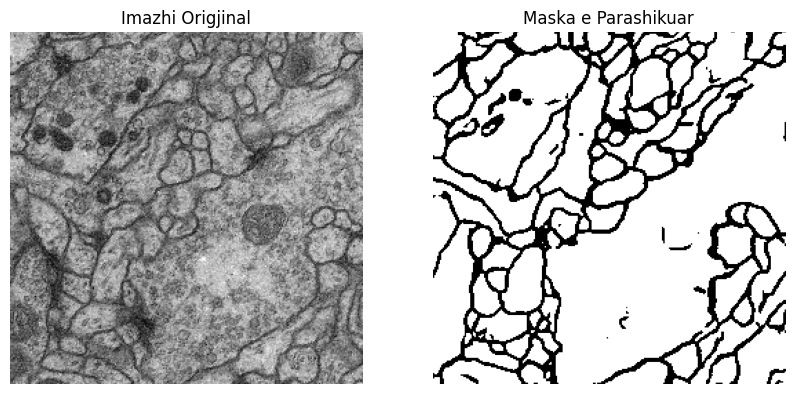

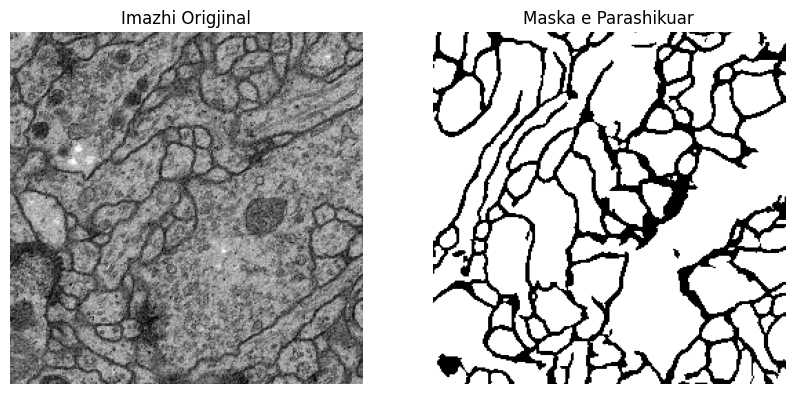

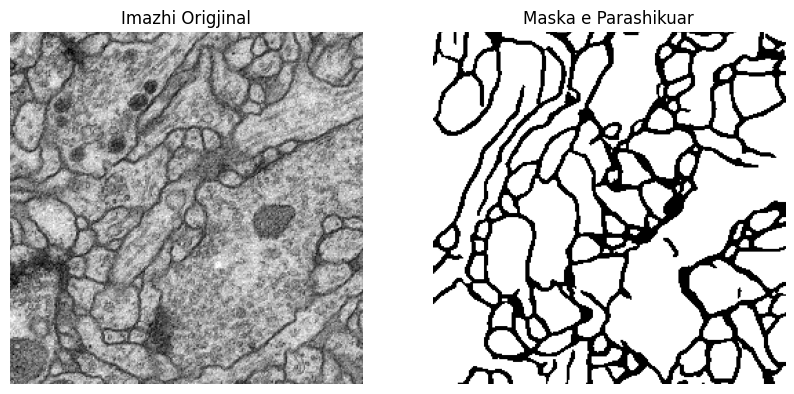

In [3]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import os

# Krijo një gjenerator për të dhënat e testimit
def testGenerator(test_path, target_size=(256, 256)):
    for filename in os.listdir(test_path):
        if filename.endswith(".png"):  # Mund të jetë çdo formati i imazhit që përdor
            img_path = os.path.join(test_path, filename)
            img = load_img(img_path, target_size=target_size, color_mode="grayscale")
            img = img_to_array(img)
            img = np.expand_dims(img, axis=0)  # Shto dimensionin për batch (1,256,256,1)
            yield img

# Krijo gjeneratorin e testit
testGene = testGenerator("data/membrane/test")

# Ngarko modelin dhe peshat
model = load_model("unet_membrana.hdf5")

# Parashiko rezultatet për testimin
results = model.predict_generator(testGene, steps=30, verbose=1)

# Printo disa maska parashikimi (për shembull, 5 të parat)
for i in range(5):
    plt.figure(figsize=(10, 5))

    # Imazhi origjinal (maskimi do të jetë për imazhe të testimit, jo etiketat e trajnimit)
    img = load_img(os.path.join("data/membrane/test", f"{i+1}.png"), color_mode="grayscale", target_size=(256, 256))
    img_array = img_to_array(img) / 255.0  # Sigurohu që imazhi është i normalizuar

    # Maskat parashikuara nga modeli
    mask = results[i].squeeze()  # Nxjerr maskën e parashikuar

    # Krijo figure dhe subplots
    plt.subplot(1, 2, 1)
    plt.title('Imazhi Origjinal')
    plt.imshow(img_array.squeeze(), cmap='gray')  # Përdorim cmap='gray' për të parë imazhet në tonet e gri
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Maska e Parashikuar')
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.show()


### per nje imazh cfardo:

1/1 [==============================] - 0s 39ms/step


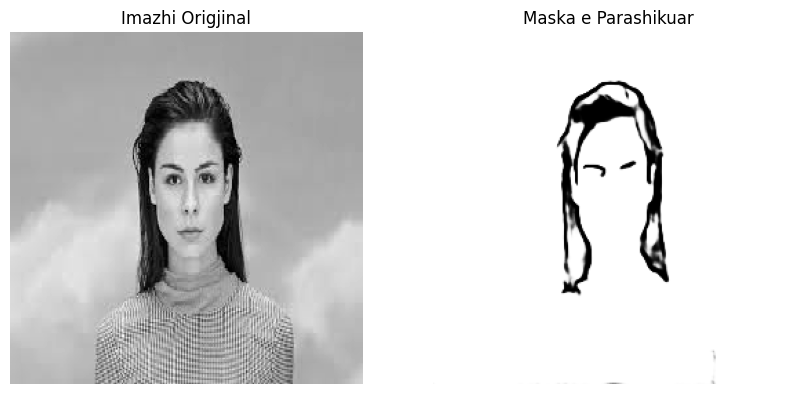

In [5]:
# Ngarko imazhin 
img_path = 'girl.jpg'  
img = load_img(img_path, target_size=(256, 256), color_mode="rgb")  # Ngarko me 3 kanale (RGB)

# Konverto në grayscale duke marrë vetëm një kanal
img = img.convert("L")  
img_array = img_to_array(img) / 255.0


# Shto një dimension për batch
img_array = np.expand_dims(img_array, axis=0)

# Parashiko rezultatin
result = model.predict(img_array)

# Shfaq imazhin origjinal dhe maskën e parashikuar

plt.figure(figsize=(10, 5))
# Imazhi origjinal
plt.subplot(1, 2, 1)
plt.title('Imazhi Origjinal')
plt.imshow(img_array.squeeze(), 'gray')  
plt.axis('off')

# Maska e parashikuar
plt.subplot(1, 2, 2)
plt.title('Maska e Parashikuar')
plt.imshow(result.squeeze(), cmap='gray') 
plt.axis('off')

plt.show()

1/1 [==============================] - 0s 44ms/step


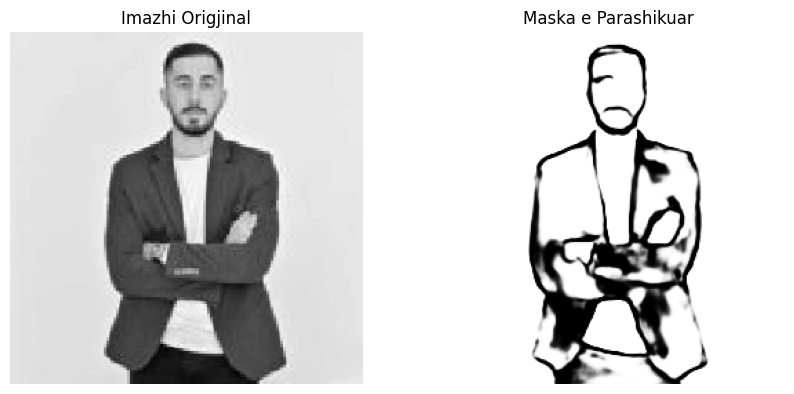

In [6]:
# Ngarko imazhin 
img_path = 'Anxhelo-Shehu-min-2-150x150.jpg'  
img = load_img(img_path, target_size=(256, 256), color_mode="rgb")  # Ngarko me 3 kanale (RGB)

# Konverto në grayscale duke marrë vetëm një kanal
img = img.convert("L")  
img_array = img_to_array(img) / 255.0


# Shto një dimension për batch
img_array = np.expand_dims(img_array, axis=0)

# Parashiko rezultatin
result = model.predict(img_array)

# Shfaq imazhin origjinal dhe maskën e parashikuar

plt.figure(figsize=(10, 5))
# Imazhi origjinal
plt.subplot(1, 2, 1)
plt.title('Imazhi Origjinal')
plt.imshow(img_array.squeeze(), 'gray')  
plt.axis('off')

# Maska e parashikuar
plt.subplot(1, 2, 2)
plt.title('Maska e Parashikuar')
plt.imshow(result.squeeze(), cmap='gray') 
plt.axis('off')

plt.show()